# Test Pipeline

End-to-end validation of the portfolio optimization pipeline, from data extraction to surrogate-based estimation.

Pipeline stages:
1. Extraction — historical price data for the selected assets.
2. DoE — design of experiments over the portfolio weight simplex.
3. Financial — portfolio metrics (variance, Sharpe, VaR, CVaR) for the sampled designs.
4. Plot Financial — visualization of the financial metrics.
5. Surrogate — Gaussian process regression fitted over the initial DoE.
6. Visualization — inspection of the fitted surrogate and optimization behavior.

The test composition uses 3 assets, keeping the weight simplex three-dimensional and therefore directly visualizable. Stages currently covered by this notebook are Extraction and DoE; later stages are left as placeholders for subsequent work.

## Imports and configurations

Loads the project modules under test and the shared configuration files (paths, stock universe) used throughout the notebook.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# a raiz do projeto e a pasta pai de Tests/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Tests" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

with open(PROJECT_ROOT / "Params" / "paths.json", "r") as f:
    paths = json.load(f)
with open(PROJECT_ROOT / "Params" / "stocks.json", "r") as f:
    stocks_cfg = json.load(f)

from Utils.extraction_module import StockDataWarehouse, StockDataFetcher 
from Utils.financial_module import StockPortfolio, PortfolioVariance, SharpeIndex, VaR, CVaR, STARRIndex, ReturnSampler
from Utils.doe_module import Sobol, LHS, SamplerShell, Map2Simplex
from Utils.plot_module import (
    StockTimeSeriesPlotter,
    plot_doe_3d,
    plot_doe_comparison_3d,
    plot_metric_comparison_3d,
    plot_gp_prior_comparison,
    plot_simplex_slices_2d,
    plot_surrogate_surface_3d_interactive,
    plot_surrogate_comparison_3d,
)
from Utils.surrogate_module import SurrogateKernels, SurrogateGPR

%matplotlib inline

SEED = 42

RF = (1 + 0.04)**(1/252) - 1 # daily safe rate for STARR Index and Sharpe Index (represents safe expecte returns on alternative investment)

## Extraction

Fetches historical adjusted close prices for the configured tickers via `StockDataFetcher` and stores them in a `StockDataWarehouse`. The resulting price panel is the raw input consumed by the financial metrics computed in later stages. The indexed price series is also plotted to check the extracted data for gaps, discontinuities, or scale mismatches between assets before it feeds the rest of the pipeline.

In [2]:
sdf = StockDataFetcher(
    start_date=stocks_cfg["start_date"],
    end_date=stocks_cfg["end_date"],
    interval=stocks_cfg["interval"],
)

sdw = StockDataWarehouse(sdf)

stocks_status = sdw.add_stocks(stocks_cfg["tickers"], auto_adjust=stocks_cfg["auto_adjust"])
if stocks_status:
    raise Exception(f"Failed to obtain data: {stocks_status}")

print(sdw.list_stocks())
print(f"{sdf.start_date} - {sdf.end_date}")

price_panel = sdw.price_panel()

price_panel.head()

['MSFT', 'JPM', 'PG']
2010-01-01 - 2026-01-01


,MSFT,JPM,PG
Date,,,
2010-01-04,23.027500,28.152380,37.580551
2010-01-05,23.034945,28.697680,37.592854
2010-01-06,22.893579,28.855360,37.414532
2010-01-07,22.655499,29.426949,37.211628
2010-01-08,22.811737,29.354687,37.162453


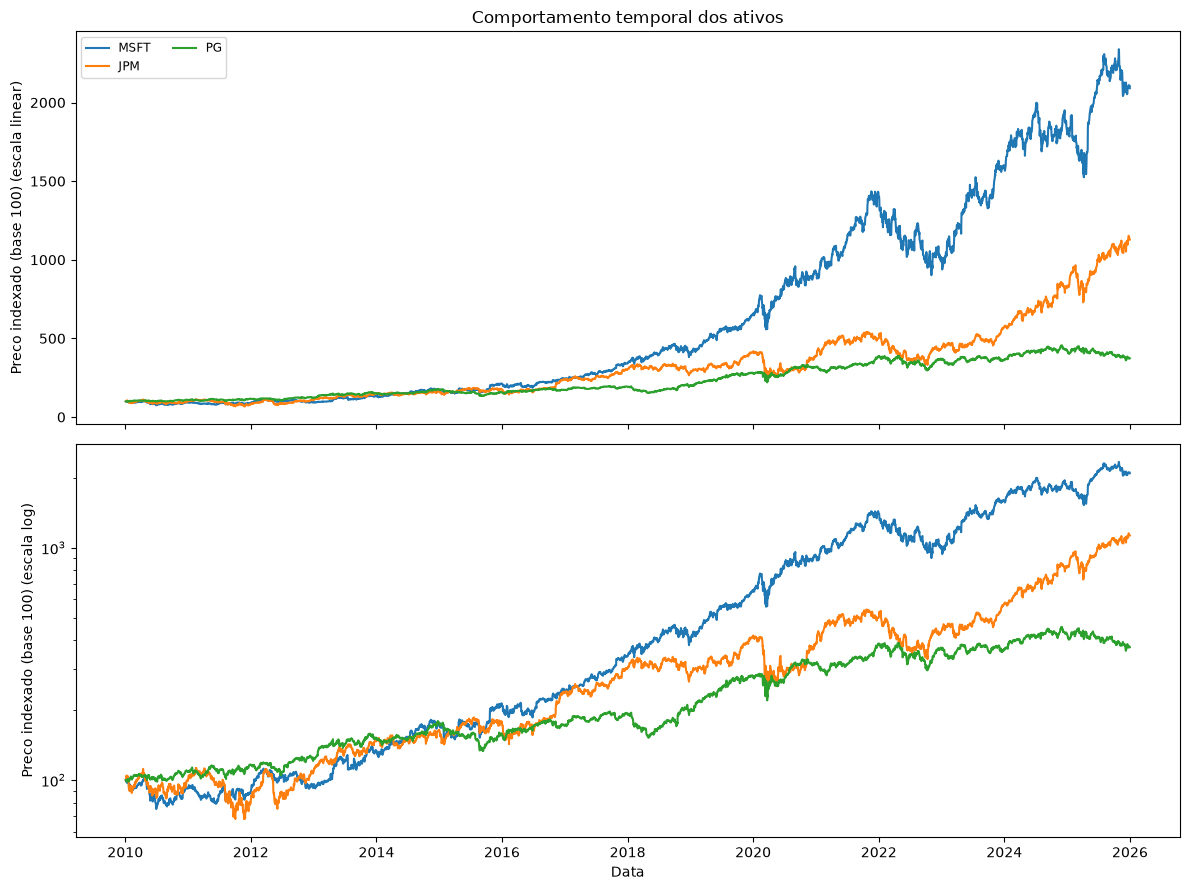

In [3]:
sts_plotter = StockTimeSeriesPlotter(sdw)
price_series_fig = sts_plotter.plot_price_series(normalize=True, log_scale=True)
plt.show()

## DoE

Builds the initial design of experiments over the portfolio weight simplex $\{w \in \mathbb{R}^3 : w_i \geq 0, \sum_i w_i = 1\}$, comparing two sampling strategies: Latin Hypercube Sampling (maximin criterion) and a scrambled Sobol sequence. Both samplers draw from the unit square and are mapped onto the simplex via `Map2Simplex`.

The sample size used here (128 points) is larger than the `n_initial_samples` value configured for the production pipeline (`Params/configs.json`); the extra points serve only to make the coverage differences between LHS and Sobol visually clear, and are not meant to represent the actual initial design used downstream.

In [4]:
sobol_shell = SamplerShell(sampler_cls=Sobol,
                           dim=3,
                           mapper_cls=Map2Simplex,
                           sampler_kwargs={"seed": SEED})

lhs_shell = SamplerShell(sampler_cls=LHS,
                         dim=3,
                         mapper_cls=Map2Simplex,
                         sampler_kwargs={"seed": SEED})

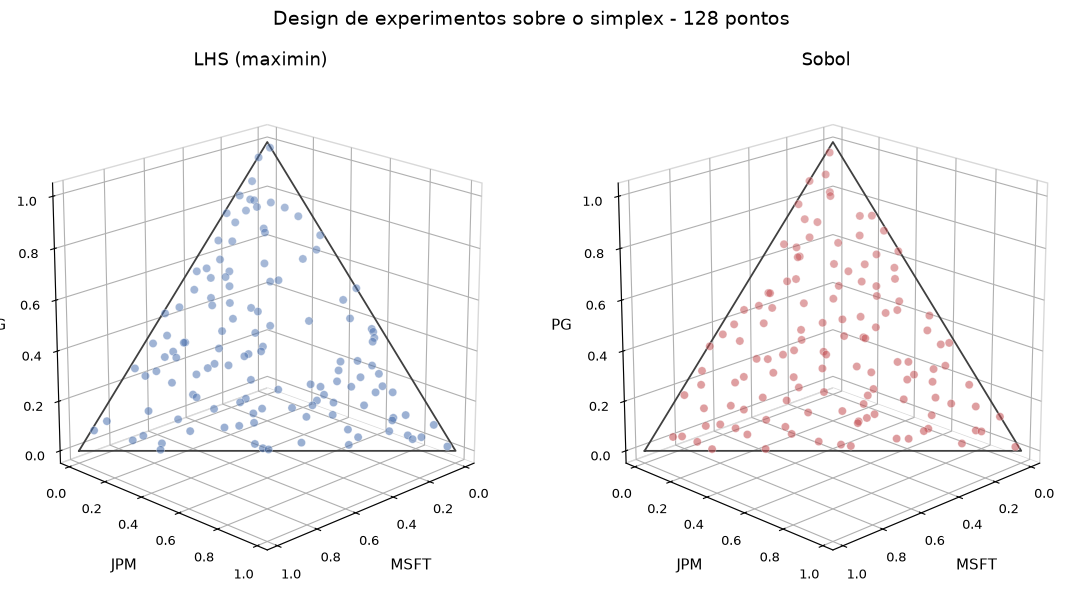

In [5]:
N_DOE_DEMO = 128  # power of 2 avoids scipy Sobol balance-property warning (sobol works best in powers of 2 to cover space more equally)

sobol_doe = sobol_shell(N_DOE_DEMO)
lhs_doe = lhs_shell(N_DOE_DEMO)

doe_fig = plot_doe_comparison_3d(
    {"LHS (maximin)": lhs_doe, "Sobol": sobol_doe},
    labels=sdw.list_stocks(),
    suptitle=f"Design de experimentos sobre o simplex - {N_DOE_DEMO} pontos",
)

`plot_doe_3d` and `plot_doe_comparison_3d` accept `elev`, `azim`, and `roll`, forwarded to `Axes3D.view_init`, so the viewing angle can be adjusted to whichever perspective best exposes a given sample. The default (`elev=20`, `azim=45`) is tuned for simplex-constrained points, rendering the simplex as a near-frontal triangle; a shallower elevation instead shows how far the Sobol sequence extends toward the simplex edges.

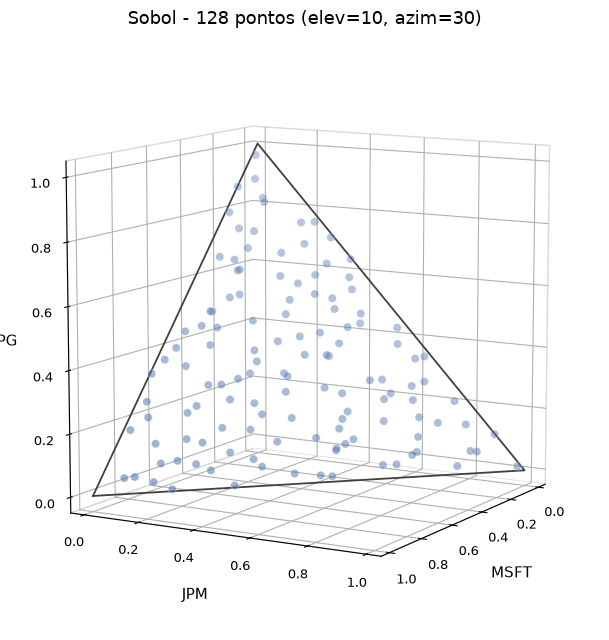

In [6]:
sobol_low_angle_fig, _ = plot_doe_3d(
    sobol_doe,
    labels=sdw.list_stocks(),
    title=f"Sobol - {N_DOE_DEMO} pontos (elev=10, azim=30)",
    elev=10,
    azim=30,
)

## Financial

Portfolio-level financial metrics for every point of the DoE, computed from the same historical return series and used downstream as the surrogate model's training targets. Two stages: aggregating the asset-level return series into a per-portfolio return series for each DoE point, then applying the risk/reward metrics themselves.

### Returns Estimation for Data Points

`ReturnSampler` converts the extracted price panel into a matrix of historical daily returns, one column per asset (its default settings sample non-overlapping 1-day windows, i.e. the plain historical series). Each DoE point is a weight vector, so its portfolio-level return series is the corresponding linear combination of the asset returns; computing `doe @ rets.T` for the whole DoE array at once yields every portfolio's return series in a single matrix product, rather than looping over points.

In [7]:
ret_sampler = ReturnSampler() # simple return sampler for historic sampling over full extracted timeseries day-by-day

rets = ret_sampler(price_panel)

print(rets.shape)

print(sobol_doe.shape)
print(lhs_doe.shape)

ret_dot_sobol = sobol_doe @ rets.T
ret_dot_lhs = lhs_doe @ rets.T

print(ret_dot_sobol.shape)
print(ret_dot_lhs.shape)

(4023, 3)
(128, 3)
(128, 3)
(128, 4023)
(128, 4023)


### Applying metrics

CVaR and the STARR ratio are each evaluated one portfolio at a time, over the rows of the return-series matrix built above (`VaR`/`CVaR`'s interface takes a single return series per call). Both use `alpha=0.95` and the non-parametric (historical) estimator; STARR additionally needs the daily risk-free rate `RF` set up in the imports cell, and defaults to the historical mean of each portfolio's own return series as its expected-return estimate. The two metrics are visualized together afterwards, over the same Sobol sample, to compare where risk (CVaR) concentrates against where risk-adjusted return (STARR) is maximized across the simplex.

In [8]:
#CVaR

cvar = CVaR(n_assets=3, alpha=0.95, type="non-parametric")

cvar_sobol = np.array([cvar(ret_)[0] for ret_ in ret_dot_sobol])
cvar_lhs =np.array([cvar(ret_)[0] for ret_ in ret_dot_lhs])


print(cvar_sobol.shape)
print(cvar_lhs.shape)

(128,)
(128,)


In [9]:
# STARR 

istarr = STARRIndex(n_assets=3, rf=RF, alpha=0.95, type="non-parametric")

istarr_sobol = np.array([istarr(ret_)[0] for ret_ in ret_dot_sobol])  # currently using average as estimation for mu 
istarr_lhs =np.array([istarr(ret_)[0] for ret_ in ret_dot_lhs])

# CAPM is further option for refining mu estimation in other implementations

print(istarr_sobol.shape)
print(istarr_lhs.shape)

(128,)
(128,)


`plot_metric_comparison_3d` colors each DoE point by a scalar value instead of scattering them uniformly, reusing the same simplex boundary, axis limits, and view-angle controls as `plot_doe_3d`/`plot_doe_comparison_3d`. It generalizes directly to visualizing a fitted surrogate's posterior mean or standard deviation later in this notebook.

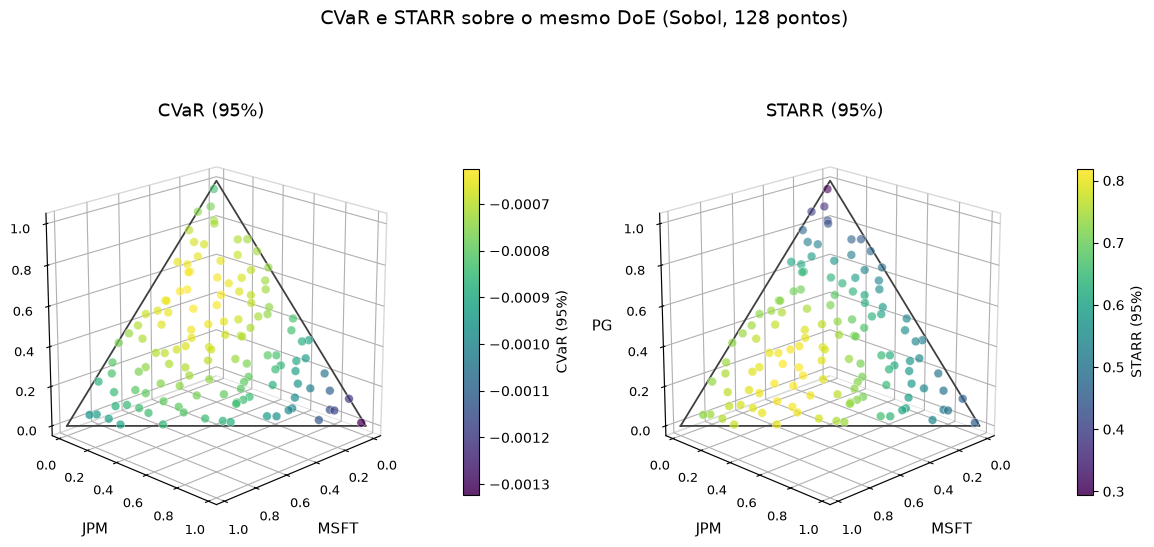

In [10]:
metrics_fig = plot_metric_comparison_3d(
    sobol_doe,
    {"CVaR (95%)": cvar_sobol, "STARR (95%)": istarr_sobol},
    labels=sdw.list_stocks(),
    suptitle=f"CVaR e STARR sobre o mesmo DoE (Sobol, {N_DOE_DEMO} pontos)",
)

## Surrogate

Fits a Gaussian process regressor over the initial DoE, using a portfolio's CVaR (or STARR) as the training target, to obtain a cheap-to-evaluate stand-in for the true objective during optimization. The kernel is the single most consequential modeling choice here: it encodes, before any data is seen, what kind of landscape the surrogate is even capable of representing (smoothness, presence of a global trend, sensitivity across assets). `SurrogateKernels` (`Utils/surrogate_module.py`) offers several ready-to-use priors built with this project's measures in mind; before fitting one to data, it helps to look at what functions it could sample on its own.

### Kernel priors

Sampling directly from a kernel's prior (mean zero, covariance given by the kernel itself, no data involved) shows its assumptions directly: `Plain` is smooth and mean-reverting with no built-in trend, `Tail` adds an unbounded linear trend on top of that same smoothness (matching how it targets tail measures like CVaR), and `Markowitz` adds a quadratic trend instead (matching the bowl shape of $w^T \Sigma w$). The 1D case below isolates this behavior along a single input axis; `plot_gp_prior_comparison` shares the y-axis scale across panels, so differences in amplitude are directly comparable, not just shape.

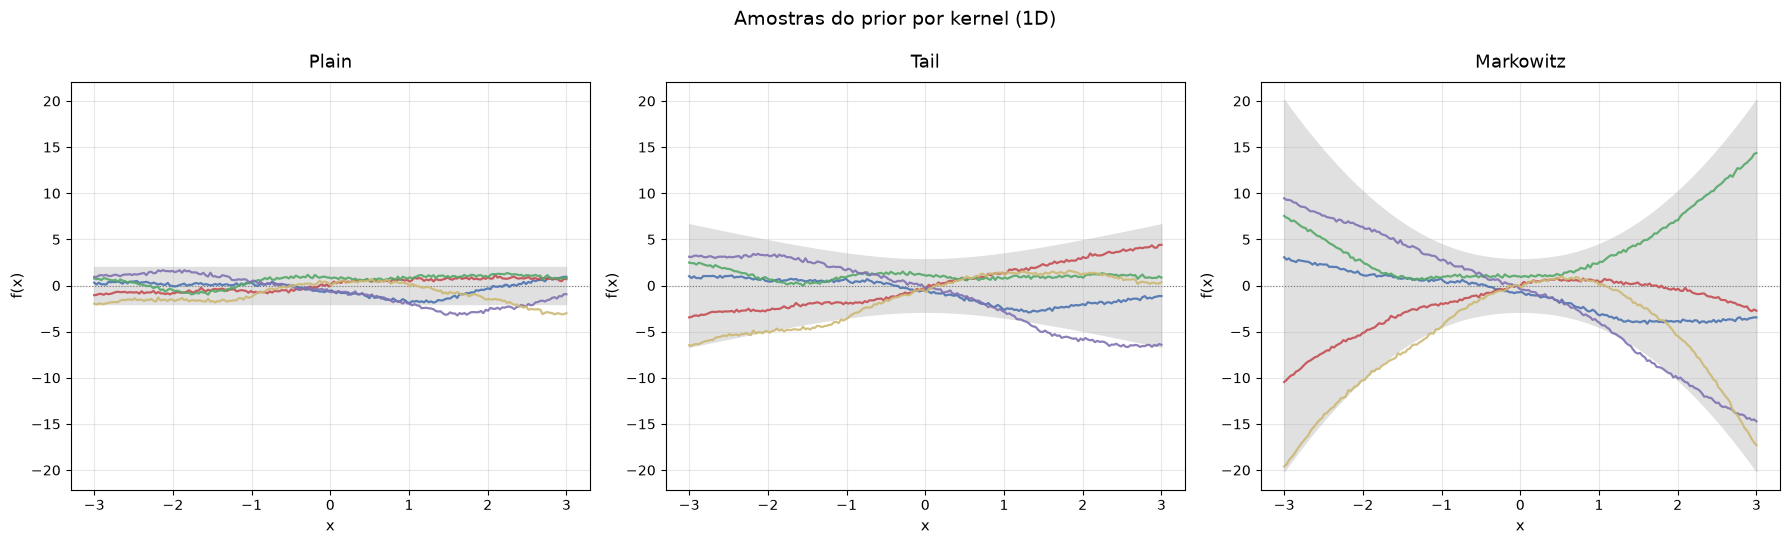

In [11]:
kernel_plain_1d = SurrogateKernels.Plain(n_dims=1)
kernel_tail_1d = SurrogateKernels.Tail(n_dims=1)
kernel_markowitz_1d = SurrogateKernels.Markowitz(n_dims=1)

gp_prior_1d_fig = plot_gp_prior_comparison(
    {"Plain": kernel_plain_1d, "Tail": kernel_tail_1d, "Markowitz": kernel_markowitz_1d},
    n_dims=1,
    suptitle="Amostras do prior por kernel (1D)",
    seed=SEED
)

The surrogate itself never actually sees a single raw input dimension: fitting it over 3-asset portfolios projects the simplex onto a 2D Helmert subspace (`SurrogateGPR._prepare`), so `n_dims=2` is the literal dimensionality it will be asked to fit. Sampling each kernel's prior over that same 2D input, as a 3D surface, previews the kind of CVaR/STARR landscape it is able to represent for this project's 3-asset case.

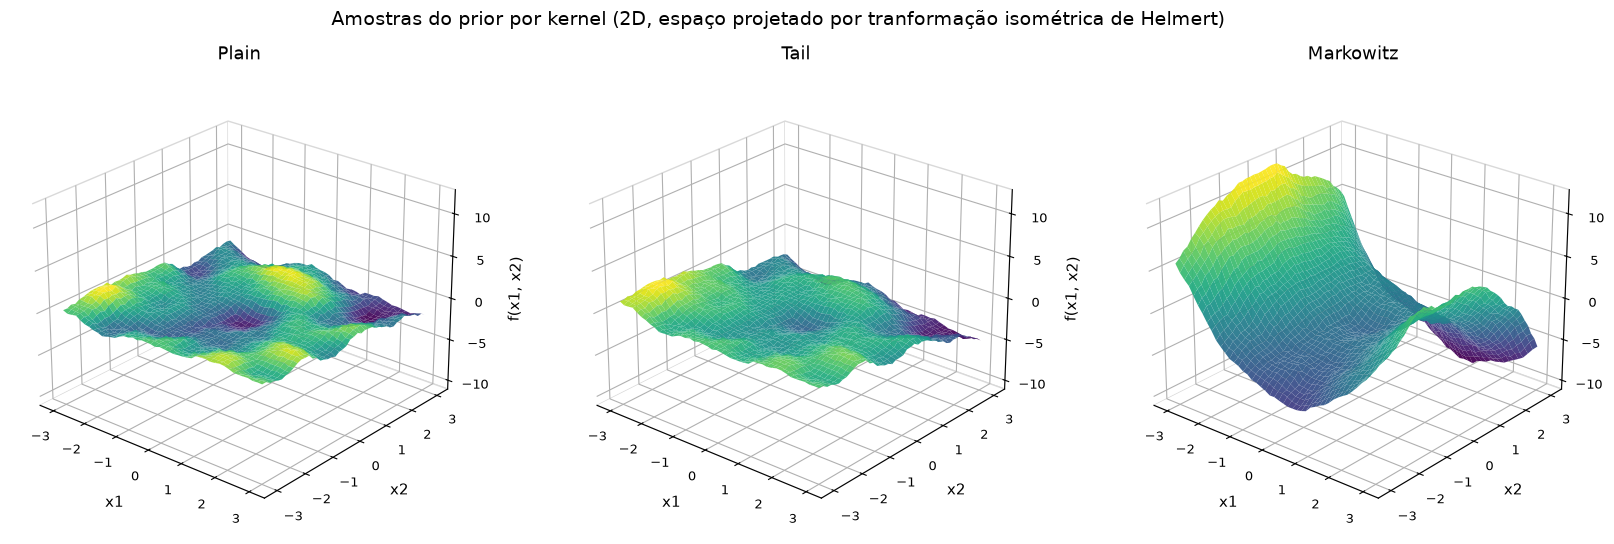

In [12]:
kernel_plain_2d = SurrogateKernels.Plain(n_dims=2)
kernel_tail_2d = SurrogateKernels.Tail(n_dims=2)
kernel_markowitz_2d = SurrogateKernels.Markowitz(n_dims=2)

gp_prior_2d_fig = plot_gp_prior_comparison(
    {"Plain": kernel_plain_2d, "Tail": kernel_tail_2d, "Markowitz": kernel_markowitz_2d},
    n_dims=2,
    suptitle="Amostras do prior por kernel (2D, espaço projetado por tranformação isométrica de Helmert)",
    seed=SEED
)

Pending: fit `SurrogateGPR` on the initial DoE (using CVaR or STARR as the training target) and inspect the resulting posterior — mean, uncertainty, and diagnostics.

In [13]:
plain_kernel = SurrogateKernels.Plain(n_dims=2)
tail_kernel = SurrogateKernels.Tail(n_dims=2)
mark_kernel = SurrogateKernels.Markowitz(n_dims=2)

cvarGPR = SurrogateGPR(mark_kernel, n_assets=3, n_restarts=10, sim_obj="cvar", random_state=SEED)
cvarGPR.fit(W=sobol_doe, y=cvar_sobol)

<Object: Model SurrogateGPR> (Objective function=cvar; status=fitted; n_assets=3; warm-start=False)
 └── <Kernel: 1**2 * Matern(length_scale=[1, 1], nu=2.5) + DotProduct(sigma_0=1) ** 2 + WhiteKernel(noise_level=0.01)>

### Fitted kernel

`fit` optimizes the kernel's hyperparameters (length-scales, amplitude, noise, and the trend terms) against the marginal likelihood, starting from the prior built above and refining it with `n_restarts` random restarts. `diagnostics()` summarizes the result: `length_scales` (smaller = the surrogate reacts more sharply to that projected coordinate), `amplitude`/`noise`/`snr` (how much of the signal's variance is attributed to structure vs. estimation error), and `log_marg_like` (useful to compare candidate kernels on the same data — higher is a better fit). `SurrogateGPR` also warns automatically whenever a fitted value lands on its search-box bound, which signals the true optimum likely lies outside the box rather than that the model converged well; those warnings, if any, are worth reading before trusting the fit below.

In [14]:
print(cvarGPR)
print("fitted kernel:", cvarGPR.kernel_)
print()
for key, value in cvarGPR.diagnostics().items():
    print(f"{key}: {value}")

<Object: Model SurrogateGPR> (Objective function=cvar; status=fitted; n_assets=3; warm-start=False)
 └── <Kernel: 1**2 * Matern(length_scale=[1, 1], nu=2.5) + DotProduct(sigma_0=1) ** 2 + WhiteKernel(noise_level=0.01)>
fitted kernel: 3.89**2 * Matern(length_scale=[1.68, 2.04], nu=2.5) + DotProduct(sigma_0=0.00132) ** 2 + WhiteKernel(noise_level=7.31e-07)

length_scales: [1.67843039 2.03640196]
n_scale_terms: 1
amplitude: 15.167644577801177
noise: 7.311394206630292e-07
snr: 20745215.138374694
log_marg_like: 437.66726188605213


Note: `print(cvarGPR)` shows `self.kernel`, the *initial* prior `fit` was started from, not `self.kernel_`. This is deliberate — `SurrogateGPR.__repr__` is meant to always report the kernel a fit began with, regardless of whether `fit` has run yet — so `cvarGPR.kernel_` (or `diagnostics()`, which reads `kernel_`) is the way to see the actual optimized hyperparameters below.

The noise level converges to ~7×10⁻⁷ here, comfortably inside its search bounds — no warning fires. Earlier runs of this fit, before `SurrogateKernels`' default `noise_bounds` was widened to `(1e-10, 1e1)` (from `(1e-6, 1e1)`), had it pinned exactly at the old lower bound instead, which is what triggered scikit-learn's "close to bound" warning. The two behaviors agree on the substance — CVaR here is computed deterministically from the same fixed historical scenario set for every portfolio, so there is no i.i.d. observation noise between calls the way there would be for, say, independently bootstrapped estimates, and a GP that drives its noise term toward (near) zero is correctly detecting that — but only the widened bound lets the optimizer actually settle there instead of being artificially stopped at the box edge.

### Fitted surface and training fit

`plot_metric_3d`-style scatter plots color points by value but flatten the surface itself into a top-down view. `plot_surrogate_surface_3d_interactive` instead renders the predicted CVaR as a literal 3D surface over one flat simplex slice, with the true (not predicted) training values scattered directly on top at their real coordinates — points sitting on the surface indicate a good fit, points floating noticeably above or below it indicate residual error the surrogate is smoothing over.

This one is interactive (drag to rotate, scroll/pinch to zoom) rather than a static image, built with Plotly instead of matplotlib specifically for this plot: matplotlib's `mplot3d` cannot do proper depth compositing between different artists, so a training marker is always drawn either fully in front of or fully behind the surface. Plotly's WebGL renderer does real per-pixel depth testing, so a point the surface actually passes through renders as genuinely half-hidden — the surface occludes the far half of the marker, not the whole thing — which is a much more honest picture of fit quality than a scatter plot's z-ordering trick.

In [15]:
surface_fig = plot_surrogate_surface_3d_interactive(
    lambda W: cvarGPR.predict(W, return_std=False),
    labels=sdw.list_stocks(),
    train_points=sobol_doe,
    train_values=cvar_sobol,
    title="Markowitz - superficie ajustada do CVaR",
    zlabel="CVaR",
)
surface_fig.show()

The 128 training points hug the surface tightly across the whole domain rather than scattering around it — a direct visual confirmation of the near-zero noise level found in the diagnostics above, since a genuinely noisy fit would show points floating visibly off the surface even where data is dense. The bowl shape itself is also much easier to read here than in the flattened contour view: CVaR rises steeply toward the back MSFT/JPM edge and crests gently across the diversified region, rather than climbing symmetrically in every direction. Dragging to a shallow, near-horizontal angle is the clearest way to check the fit edge-on: any point sitting off the surface would show as a visible gap at that angle, and none do.

### Posterior mean and uncertainty over the simplex

`predict(..., return_std=True)` is evaluated on a fresh, denser Sobol sample (256 points, different seed from the training DoE) rather than the 128 training points themselves, since the interesting behavior of a surrogate is exactly how it fills in the gaps between observations. The posterior mean and standard deviation are plotted side by side with `plot_metric_comparison_3d`, reusing the exact same simplex/view-angle machinery as the DoE and CVaR/STARR plots above.

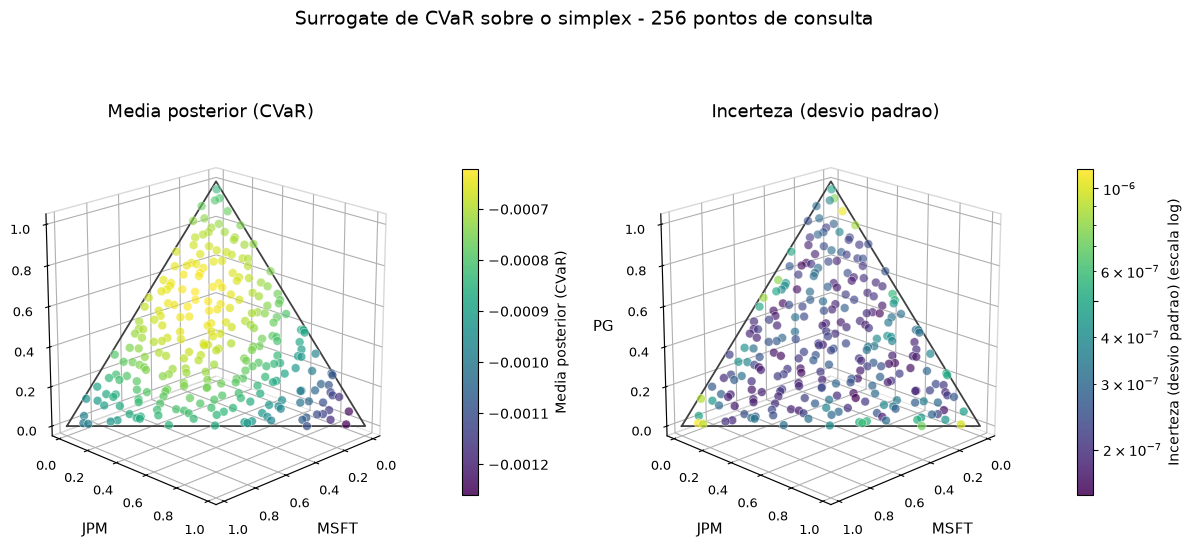

In [16]:
N_QUERY_DEMO = 256  # power of 2, denser than the training DoE to probe unsampled regions

query_shell = SamplerShell(sampler_cls=Sobol, dim=3, mapper_cls=Map2Simplex, sampler_kwargs={"seed": SEED + 1})
query_doe = query_shell(N_QUERY_DEMO)

posterior_mean, posterior_std = cvarGPR.predict(query_doe, return_std=True)

posterior_fig = plot_metric_comparison_3d(
    query_doe,
    {"Media posterior (CVaR)": posterior_mean, "Incerteza (desvio padrao)": posterior_std},
    labels=sdw.list_stocks(),
    log_scale={"Incerteza (desvio padrao)": True},
    suptitle=f"Surrogate de CVaR sobre o simplex - {N_QUERY_DEMO} pontos de consulta",
)

The posterior mean traces a clear gradient across the simplex rather than a flat or noisy surface: CVaR is worst (most negative) toward pure JPM, best toward pure PG, with MSFT in between — at the 3 vertices the surrogate predicts −0.135%, −0.087%, and −0.105% respectively, matching the true historical CVaR at those same points almost exactly (e.g. −0.1352% predicted vs. −0.1352% true for 100% JPM). More strikingly, the equal-weighted portfolio's predicted CVaR (−0.067%) is materially better than *any* single-asset corner, including PG's — a direct, quantified diversification effect the surrogate recovered without being told about it explicitly.

On a linear color scale the uncertainty panel above looked almost uniformly flat; on the log scale used here it spans close to an order of magnitude (from ~1.5×10⁻⁷ to ~1.1×10⁻⁶), and a distinct bright spike stands out right at the MSFT vertex. Checking the training sample directly confirms this is not a modeling artifact: the closest Sobol point to pure MSFT sits 0.12 away in weight-space, versus 0.03 for JPM and 0.04 for PG — MSFT genuinely is the sparsest corner of this particular 128-point draw. That is exactly the shape a GP's uncertainty should take: low and fairly even across the well-covered interior, rising specifically where training coverage thins out, not a uniform haze.

### Flat 2D projections

The simplex constraint $\sum_i w_i = 1$ makes one of the 3 asset weights linearly dependent on the other two, so the whole simplex is fully described by any 2 of the 3 weights. There is no privileged pair, though: dropping MSFT, JPM, or PG each gives a different, equally valid flat (undistorted, no 3D perspective) view of the same surface. `plot_simplex_slices_2d` plots all three, sharing one color scale, with the training DoE overlaid so the posterior can be read directly against where data was actually observed.

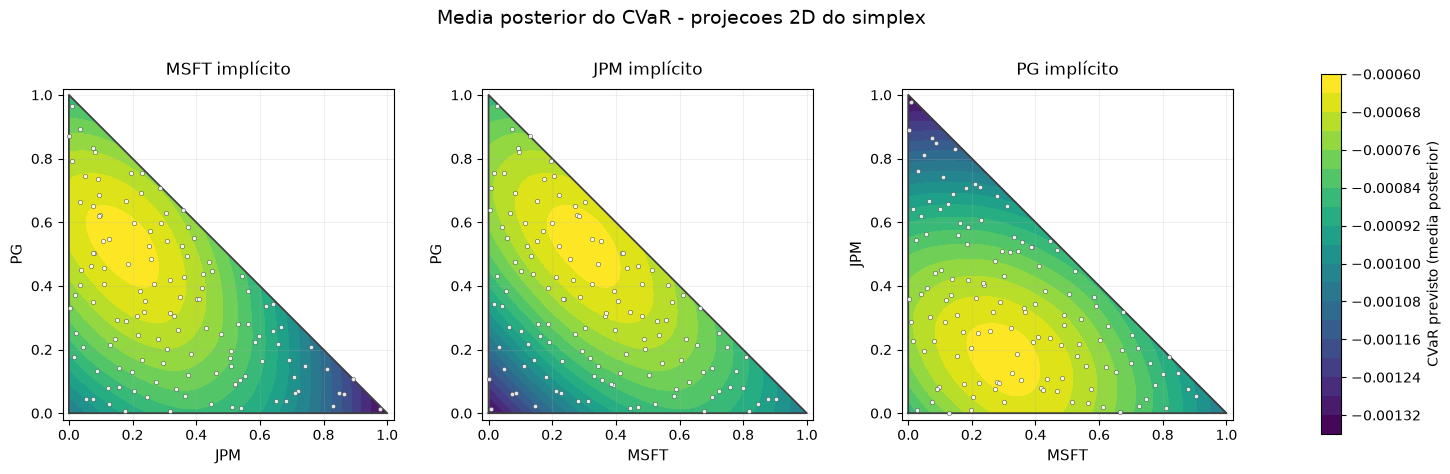

In [17]:
slices_mean_fig = plot_simplex_slices_2d(
    lambda W: cvarGPR.predict(W, return_std=True)[0],
    labels=sdw.list_stocks(),
    overlay_points=sobol_doe,
    colorbar_label="CVaR previsto (media posterior)",
    suptitle="Media posterior do CVaR - projecoes 2D do simplex",
)

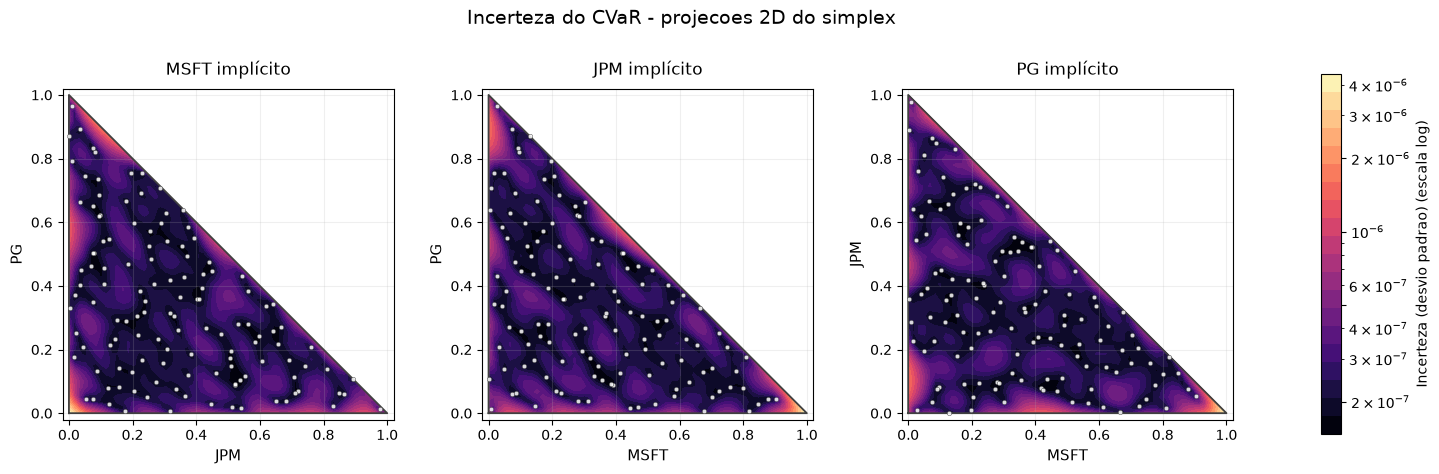

In [18]:
slices_std_fig = plot_simplex_slices_2d(
    lambda W: cvarGPR.predict(W, return_std=True)[1],
    labels=sdw.list_stocks(),
    overlay_points=sobol_doe,
    colorbar_label="Incerteza (desvio padrao)",
    cmap="magma",
    log_scale=True,
    suptitle="Incerteza do CVaR - projecoes 2D do simplex",
)

All three panels agree, as they must — they are 3 flat views of the same 2D surface, not 3 different pieces of information. Each confirms the same pattern read off the 3D plot: the best-CVaR region sits inside the simplex, skewed toward PG and away from the JPM edge, rather than at any single vertex, and every panel's worst corner is the one where JPM approaches 100%.

The log-scale uncertainty panels make the same point the 3D view did, but with much finer spatial detail: bright, speckled pockets of higher uncertainty (orange/red) sit specifically in the visible gaps between overlaid Sobol points, while the near-black regions track the densest clusters — the model's confidence is following the actual local sample density, not just an overall distance-to-centroid effect. Under the earlier linear scale that same variation was compressed into what looked like a single dark color everywhere.

This is the surface a subsequent acquisition function would search over: since CVaR already varies smoothly and predictably across the simplex with this fit, the more informative next step is less about denser initial sampling here and more about widening the pinned kernel bounds noted above before trusting the surrogate's absolute values.

### Kernel comparison

Everything above used the `Markowitz` kernel alone; `Plain` and `Tail` (built earlier, for the prior-sampling comparison) are now fit on the exact same DoE and CVaR target, so their adequacy can be judged against it rather than assumed from the prior alone. `log_marg_like` (higher is better, directly comparable since all three are fit on identical data) is the quantitative side of the comparison; `plot_surrogate_comparison_3d` is the visual side, putting all three fitted surfaces side by side with the same true training points overlaid and the same z-limits, so shape differences are not an artifact of each panel auto-scaling independently. This one stays a static matplotlib figure rather than the interactive Plotly version used above: three independent 3D scenes fighting for the same mouse drag does not work well as an interaction, whereas a single fixed, well-chosen viewing angle compares all three at a glance.

In [19]:
plain_gpr = SurrogateGPR(plain_kernel, n_assets=3, n_restarts=10, sim_obj="cvar", random_state=SEED).fit(W=sobol_doe, y=cvar_sobol)
tail_gpr = SurrogateGPR(tail_kernel, n_assets=3, n_restarts=10, sim_obj="cvar", random_state=SEED).fit(W=sobol_doe, y=cvar_sobol)

for name, model in [("Plain", plain_gpr), ("Tail", tail_gpr), ("Markowitz", cvarGPR)]:
    d = model.diagnostics()
    print(f"{name:10s} log_marg_like={d['log_marg_like']:9.2f}  snr={d['snr']:.3g}  length_scales={d['length_scales']}")

C:\Documents\Poli\PosGrad\Codigo projeto\pvenv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 24 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Documents\Poli\PosGrad\Codigo projeto\pvenv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Documents\Poli\PosGrad\Codigo projeto\pvenv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 27 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Documents\Poli\PosGrad\Codigo projeto\pvenv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Plain      log_marg_like=   436.25  snr=1.24e+08  length_scales=[2.43898521 2.92738481]
Tail       log_marg_like=   436.91  snr=6.28e+07  length_scales=[2.10935669 2.53087937]
Markowitz  log_marg_like=   437.67  snr=2.07e+07  length_scales=[1.67843039 2.03640196]


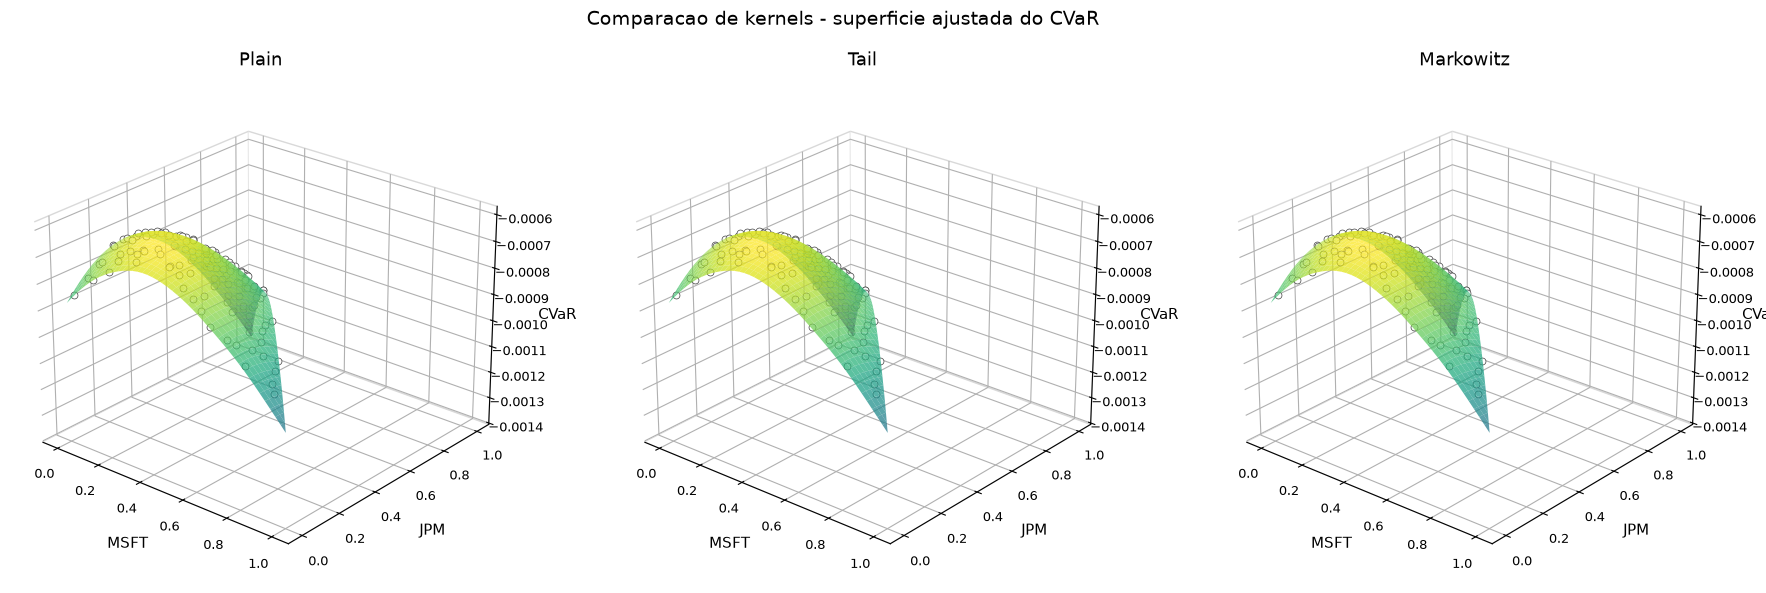

In [20]:
kernel_comparison_fig = plot_surrogate_comparison_3d(
    {
        "Plain": lambda W: plain_gpr.predict(W, return_std=False),
        "Tail": lambda W: tail_gpr.predict(W, return_std=False),
        "Markowitz": lambda W: cvarGPR.predict(W, return_std=False),
    },
    labels=sdw.list_stocks(),
    train_points=sobol_doe,
    train_values=cvar_sobol,
    zlabel="CVaR",
    suptitle="Comparacao de kernels - superficie ajustada do CVaR",
)

`Markowitz` wins on `log_marg_like` (437.67) over `Tail` (436.91) and `Plain` (436.25) — a real, quantitative confirmation, not just the construction-based intuition that CVaR "should" behave like a bowl. The residual Matern length-scales tell the same story from a different angle, shrinking monotonically as each kernel's own trend term gets more expressive: `Plain` [2.44, 2.93] → `Tail` [2.11, 2.53] → `Markowitz` [1.68, 2.04]. With no trend at all, `Plain`'s Matern alone has to stretch to explain the broad bowl shape; `Markowitz`'s quadratic term already accounts for most of it, leaving its residual free to specialize in shorter-range, finer structure instead. `Tail`'s own trend parameter also moved a lot once its search bound was widened, from pinned near `0.001` to a freely-chosen `10.3` — a sign its old fit was genuinely bound-constrained, unlike `Markowitz`'s `sigma_0`, which barely moved and so was never really pinned in the first place (see the bounds note above).

Visually, though, the three fitted surfaces above look nearly indistinguishable near the training data — expected, since all three interpolate the same 128 points almost exactly (noise pinned near zero in every fit), so close to data any sufficiently flexible kernel converges to roughly the same answer. The gap between them is a fitting-quality signal more than a visible-shape signal here; it would matter more once predictions are read further from the training points, e.g. at the sparse MSFT vertex identified above, where each kernel's trend assumption increasingly drives the extrapolation. On both grounds, `Markowitz` remains the kernel to prefer for this measure and this DoE.

### Why is there no visible Matérn texture?

Every kernel here is `(trend) + Matérn 5/2 (ARD) + noise`, so "no visible waviness" raises a fair question: is the Matérn term actually doing anything? Decomposing the fitted posterior mean back into its additive pieces answers this directly — for an additive kernel, each component's contribution to the mean is `K_component(X_query, X_train) @ alpha_`, using the *same* fitted `alpha_` the full model uses, so the pieces sum back to the total prediction exactly.

In [21]:
from scipy.linalg import helmert

U = helmert(3)
domain_span = np.ptp(sobol_doe @ U.T, axis=0)  # extent of the training DoE in the projected (Helmert) input space
print("Helmert-projected domain span:", domain_span)
print()
for name, model in [("Plain", plain_gpr), ("Tail", tail_gpr), ("Markowitz", cvarGPR)]:
    ls = model.diagnostics()["length_scales"]
    print(f"{name:10s} length_scales={ls}  domain/length_scale ratio={domain_span / ls}")

# decompose the Markowitz posterior mean into its trend-only and Matern-only contributions
gpr = cvarGPR.gp_
trend_k, matern_k = gpr.kernel_.k1.k2, gpr.kernel_.k1.k1  # DotProduct**2, ConstantKernel*Matern
Xq, Xtr, alpha = cvarGPR._prepare(query_doe), gpr.X_train_, gpr.alpha_.ravel()
trend_contrib = trend_k(Xq, Xtr) @ alpha * gpr._y_train_std
matern_contrib = matern_k(Xq, Xtr) @ alpha * gpr._y_train_std

print()
print(f"trend contribution:  range={trend_contrib.max() - trend_contrib.min():.3e}  std={trend_contrib.std():.3e}")
print(f"Matern contribution: range={matern_contrib.max() - matern_contrib.min():.3e}  std={matern_contrib.std():.3e}")

Helmert-projected domain span: [1.28628319 1.17520782]

Plain      length_scales=[2.43898521 2.92738481]  domain/length_scale ratio=[0.52738458 0.40145314]
Tail       length_scales=[2.10935669 2.53087937]  domain/length_scale ratio=[0.6097988  0.46434762]
Markowitz  length_scales=[1.67843039 2.03640196]  domain/length_scale ratio=[0.76636076 0.57710012]

trend contribution:  range=1.353e-04  std=2.865e-05
Matern contribution: range=5.268e-04  std=1.170e-04


Two things together explain it, and the numbers above confirm both.

First, the Matérn term is not idle — for `Markowitz` its contribution actually has a *larger* range than the quadratic trend's (≈5.3×10⁻⁴ vs. ≈1.4×10⁻⁴), and the two sum back exactly to the total prediction. It is doing real work; it is just not doing it as visible "texture."

Second, and this is the actual reason no texture shows: a Matérn 5/2's characteristic scale of variation *is* its length-scale, and every fitted length-scale here (`Plain` [2.44, 2.93], `Tail` [2.11, 2.53], `Markowitz` [1.68, 2.04]) is longer than the training DoE's own span in the same projected coordinates (≈[1.29, 1.18]) — the domain/length-scale ratio never exceeds ≈0.77. The whole simplex fits inside less than one characteristic wavelength of the kernel in every case, so a Matérn component large enough to matter still only has room to contribute a single broad, monotonic-looking swing across the observed region, not multiple bumps. That swing is what makes `Plain` alone already produce a recognizable bowl even with no explicit trend term at all — and why adding one (`Tail`, then `Markowitz`) mainly reassigns *how efficiently* that same shape gets explained (higher `log_marg_like`, shorter residual length-scales) rather than visibly changing the shape itself. The three panels above look alike because, with 128 points spread this thinly relative to the kernel's own reach, there simply is not enough resolution in the data to *require* more structure than one smooth bowl — any of these kernels is flexible enough to provide it.

## Surrogate — STARR

Same procedure as above, now training on `istarr_sobol` (the STARR ratio) instead of CVaR: same DoE, same three kernels, same diagnostics, same visualizations. Steps that only re-explain a mechanism already covered for CVaR are kept brief here; the numbers themselves are recomputed and reported in full, since a ratio measure driven by both return and risk has no reason to favor the same kernel, or land on the same shape, as a pure risk measure.

In [22]:
istarrGPR = SurrogateGPR(mark_kernel, n_assets=3, n_restarts=10, sim_obj="starr", random_state=SEED)
istarrGPR.fit(W=sobol_doe, y=istarr_sobol)

<Object: Model SurrogateGPR> (Objective function=starr; status=fitted; n_assets=3; warm-start=False)
 └── <Kernel: 1**2 * Matern(length_scale=[1, 1], nu=2.5) + DotProduct(sigma_0=1) ** 2 + WhiteKernel(noise_level=0.01)>

### Fitted kernel

Same `Markowitz` kernel and settings used first for CVaR (`length_scales`, `amplitude`/`noise`/`snr`, `log_marg_like` — see the CVaR section above for what each means).

In [23]:
print(istarrGPR)
print("fitted kernel:", istarrGPR.kernel_)
print()
for key, value in istarrGPR.diagnostics().items():
    print(f"{key}: {value}")

<Object: Model SurrogateGPR> (Objective function=starr; status=fitted; n_assets=3; warm-start=False)
 └── <Kernel: 1**2 * Matern(length_scale=[1, 1], nu=2.5) + DotProduct(sigma_0=1) ** 2 + WhiteKernel(noise_level=0.01)>
fitted kernel: 2.49**2 * Matern(length_scale=[1.33, 1.63], nu=2.5) + DotProduct(sigma_0=0.59) ** 2 + WhiteKernel(noise_level=6.51e-07)

length_scales: [1.33410228 1.63482825]
n_scale_terms: 1
amplitude: 6.182152463649044
noise: 6.512476309291221e-07
snr: 9492783.036813647
log_marg_like: 432.5375634789894


`sigma_0` lands at `0.59` here, orders of magnitude above the `~0.001` found for CVaR's `Markowitz` fit — expected, since `sigma_0` is a bias term inside `(sigma_0 + x·x')²`, and CVaR (a risk-only measure) is well described by an almost-unbiased quadratic through the origin, while STARR mixes in the linear expected-return term as well, which a purely-through-the-origin quadratic cannot represent on its own; the DotProduct needs a real bias to compensate. `noise` again converges away from its bound (~6.5×10⁻⁷), for the same reason as before: STARR is just as deterministic a function of the fixed historical scenario set as CVaR is.

### Fitted surface and training fit

In [24]:
starr_surface_fig = plot_surrogate_surface_3d_interactive(
    lambda W: istarrGPR.predict(W, return_std=False),
    labels=sdw.list_stocks(),
    train_points=sobol_doe,
    train_values=istarr_sobol,
    title="Markowitz - superficie ajustada do STARR",
    zlabel="STARR",
)
starr_surface_fig.show()

The ranking flips relative to CVaR: at the 3 vertices the surrogate predicts STARR of 0.69 (MSFT), 0.44 (JPM), 0.26 (PG) — MSFT is now the *best* single asset and PG the *worst*, the reverse of the CVaR ordering, where PG had the best (least negative) risk and JPM the worst. That is STARR doing exactly what it is built for: CVaR alone ignores expected return, and MSFT's higher return apparently outweighs its middling risk once the two are combined into a ratio. The diversification effect shows up again regardless — the equal-weighted portfolio's predicted STARR (0.77) still beats every single-asset corner, including MSFT's — but this time the surrogate is reconciling a return effect and a risk effect at once rather than risk alone, which is a meaningfully different landscape to have fit well.

### Posterior mean and uncertainty over the simplex

Same `query_doe` (256 points) used for CVaR, so the two objectives' predictions are read over identical query locations.

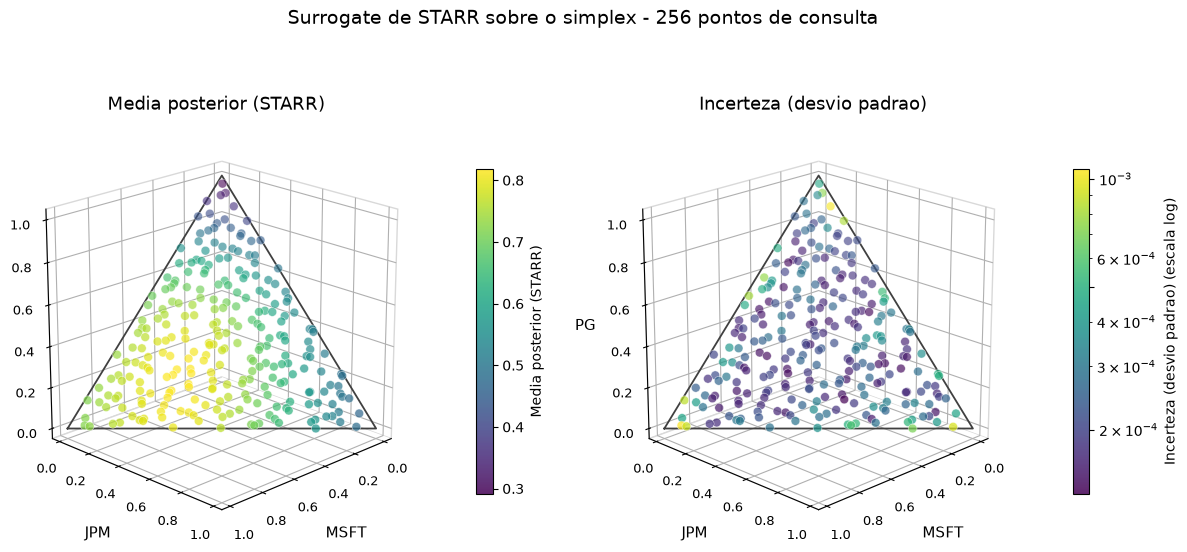

In [25]:
starr_posterior_mean, starr_posterior_std = istarrGPR.predict(query_doe, return_std=True)

starr_posterior_fig = plot_metric_comparison_3d(
    query_doe,
    {"Media posterior (STARR)": starr_posterior_mean, "Incerteza (desvio padrao)": starr_posterior_std},
    labels=sdw.list_stocks(),
    log_scale={"Incerteza (desvio padrao)": True},
    suptitle=f"Surrogate de STARR sobre o simplex - {N_QUERY_DEMO} pontos de consulta",
)

Uncertainty peaks at the same MSFT vertex identified for CVaR, as expected — it is the same training points at the same locations, so the same corner is undersampled regardless of which target is being predicted. The absolute scale is different simply because STARR itself lives on a different scale than CVaR (order 10⁻¹ vs. order 10⁻³), not because the model is more or less confident in a relative sense.

### Flat 2D projections

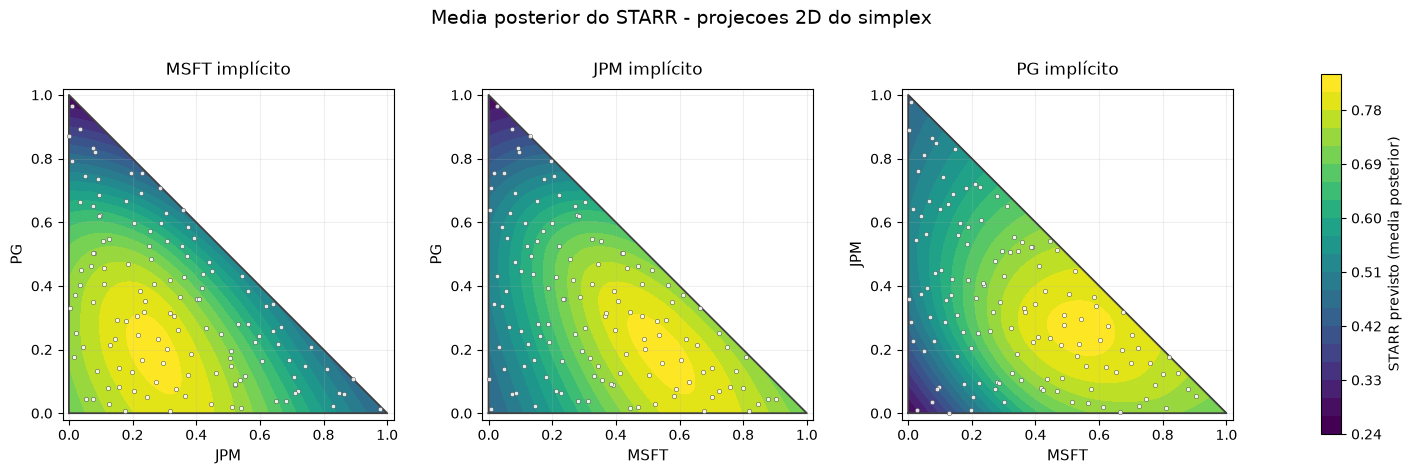

In [26]:
starr_slices_mean_fig = plot_simplex_slices_2d(
    lambda W: istarrGPR.predict(W, return_std=True)[0],
    labels=sdw.list_stocks(),
    overlay_points=sobol_doe,
    colorbar_label="STARR previsto (media posterior)",
    suptitle="Media posterior do STARR - projecoes 2D do simplex",
)

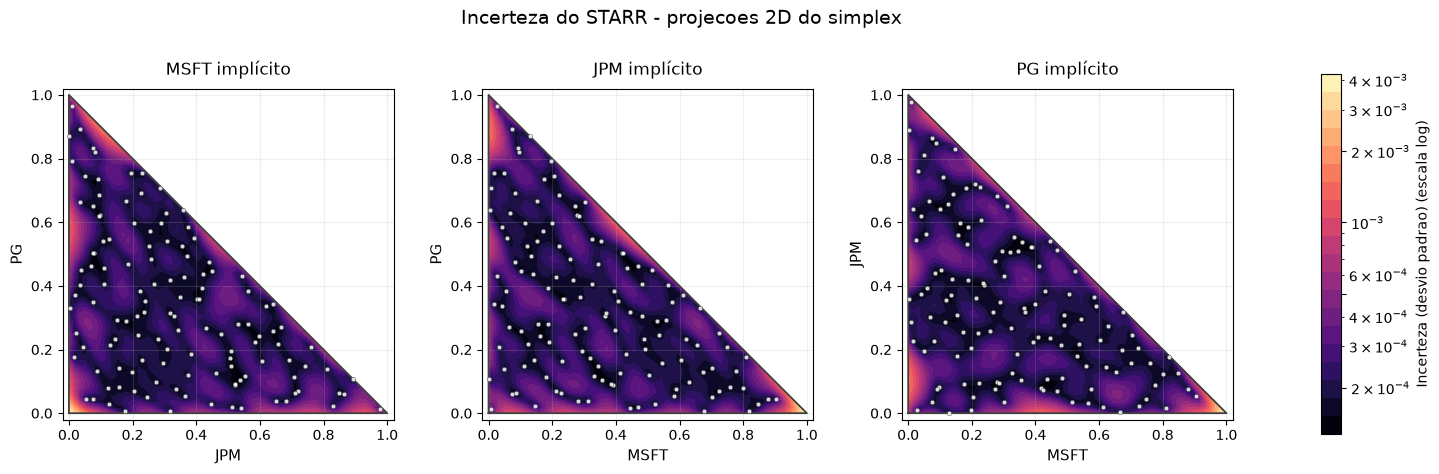

In [27]:
starr_slices_std_fig = plot_simplex_slices_2d(
    lambda W: istarrGPR.predict(W, return_std=True)[1],
    labels=sdw.list_stocks(),
    overlay_points=sobol_doe,
    colorbar_label="Incerteza (desvio padrao)",
    cmap="magma",
    log_scale=True,
    suptitle="Incerteza do STARR - projecoes 2D do simplex",
)

Same reading as for CVaR applies to the mechanics of these panels (3 equally valid flat views, shared color scale, uncertainty tracking local sample density), so it is not repeated here. The one substantive difference is the mean panel's gradient direction: it now points toward MSFT rather than PG, mirroring the flipped vertex ranking found above.

### Kernel comparison

`Plain` and `Tail` are fit on the same DoE and STARR target, exactly as done for CVaR.

In [28]:
plain_gpr_starr = SurrogateGPR(plain_kernel, n_assets=3, n_restarts=10, sim_obj="starr", random_state=SEED).fit(W=sobol_doe, y=istarr_sobol)
tail_gpr_starr = SurrogateGPR(tail_kernel, n_assets=3, n_restarts=10, sim_obj="starr", random_state=SEED).fit(W=sobol_doe, y=istarr_sobol)

for name, model in [("Plain", plain_gpr_starr), ("Tail", tail_gpr_starr), ("Markowitz", istarrGPR)]:
    d = model.diagnostics()
    print(f"{name:10s} log_marg_like={d['log_marg_like']:9.2f}  snr={d['snr']:.3g}  length_scales={d['length_scales']}")

C:\Documents\Poli\PosGrad\Codigo projeto\pvenv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 38 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Documents\Poli\PosGrad\Codigo projeto\pvenv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 23 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Plain      log_marg_like=   432.49  snr=1.93e+07  length_scales=[1.5604207  1.91507881]
Tail       log_marg_like=   432.69  snr=1.2e+07  length_scales=[1.40526425 1.72461354]
Markowitz  log_marg_like=   432.54  snr=9.49e+06  length_scales=[1.33410228 1.63482825]


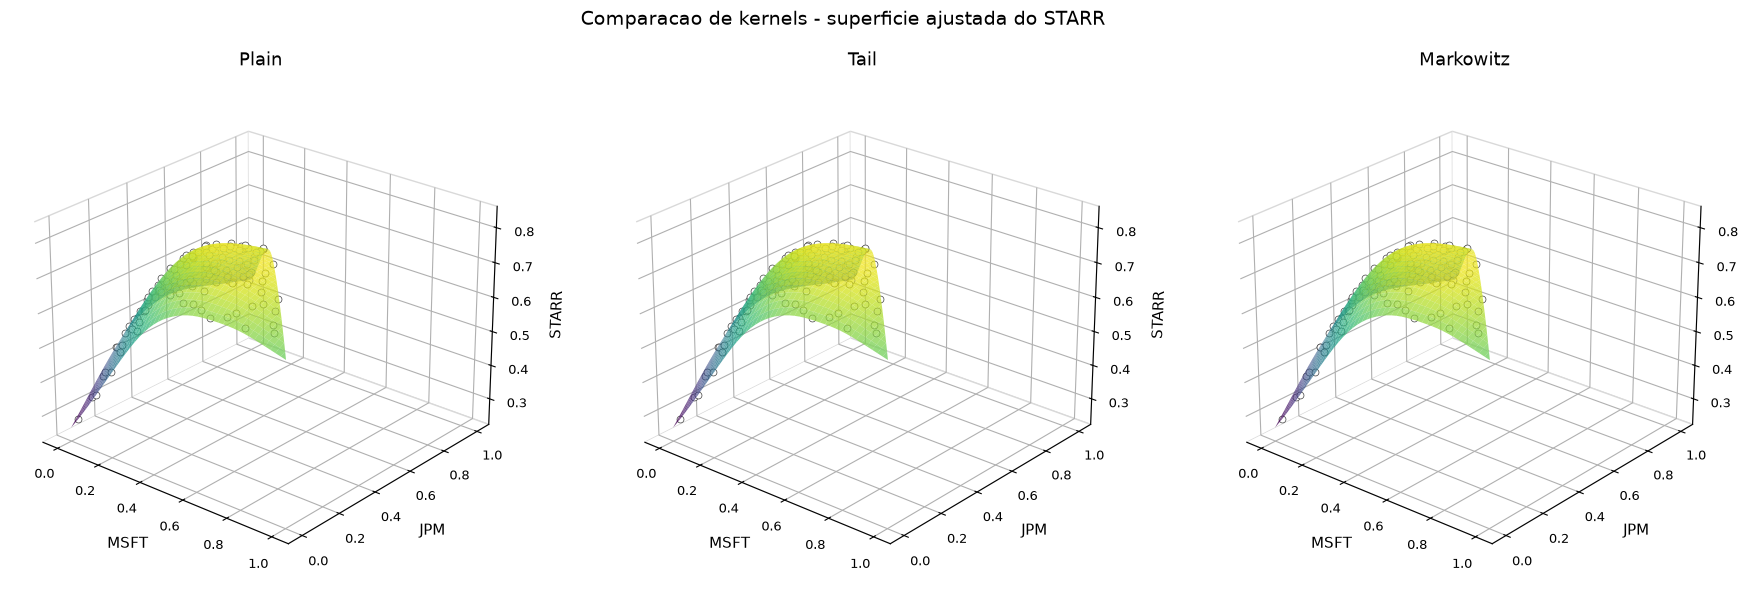

In [29]:
starr_kernel_comparison_fig = plot_surrogate_comparison_3d(
    {
        "Plain": lambda W: plain_gpr_starr.predict(W, return_std=False),
        "Tail": lambda W: tail_gpr_starr.predict(W, return_std=False),
        "Markowitz": lambda W: istarrGPR.predict(W, return_std=False),
    },
    labels=sdw.list_stocks(),
    train_points=sobol_doe,
    train_values=istarr_sobol,
    zlabel="STARR",
    suptitle="Comparacao de kernels - superficie ajustada do STARR",
)

Unlike CVaR, `Tail` wins here (`log_marg_like` 432.69) over `Markowitz` (432.54) and `Plain` (432.49) — the opposite ranking from before, and it lines up exactly with how the two kernels were designed: `Markowitz`'s squared DotProduct targets a measure dominated by a variance-like quadratic form, while `Tail`'s plain (unsquared) DotProduct targets "ratio/tail measures (Sharpe, VaR, CVaR, STARR)" per its own docstring — a linear trend, not a bowl. STARR being a ratio of a linear (return) term over a risk term apparently behaves more like `Tail`'s assumption than `Markowitz`'s. That said, the gap between all three (0.2 in `log_marg_like`) is much narrower than CVaR's (1.4), so the preference is real but far less decisive — consistent with `Plain`, which has no trend term at all, still landing within 0.2 of the winner. `Markowitz` remained a reasonable choice used throughout the exploration above; a production pipeline picking a single kernel per objective would switch to `Tail` for STARR specifically.

In [30]:
for name, model in [("Plain", plain_gpr_starr), ("Tail", tail_gpr_starr), ("Markowitz", istarrGPR)]:
    ls = model.diagnostics()["length_scales"]
    print(f"{name:10s} length_scales={ls}  domain/length_scale ratio={domain_span / ls}")

Plain      length_scales=[1.5604207  1.91507881]  domain/length_scale ratio=[0.8243182  0.61366029]
Tail       length_scales=[1.40526425 1.72461354]  domain/length_scale ratio=[0.9153319  0.68143256]
Markowitz  length_scales=[1.33410228 1.63482825]  domain/length_scale ratio=[0.96415636 0.71885705]


The same "no visible texture" reasoning from the CVaR section applies here too, with one difference worth flagging: STARR's fitted length-scales are shorter than CVaR's were, so the domain/length-scale ratio climbs as high as ≈0.96 (`Markowitz`, first coordinate) — the training DoE now spans nearly one full characteristic wavelength, rather than at most ≈0.77 for CVaR. STARR's fitted surfaces are, in that precise sense, closer to the point where local Matérn structure would start becoming visible than CVaR's were, even though neither is quite there with only 128 points.

## Otimização sobre superfície aproximada

Com a superfície gerada pelo GPR é possível com mais rapidez gerar grandes quantidades de estimativas sem o custo computacional do processo de cálculo real das métricas financeiras. A otimização sobre a superfície continua que descreve aproximadamente o comportamento real da métrica é uma tarefa mais simples e justifica a criação do surrogate. Até agora, para saber o CVaR de uma carteira w, era preciso pegar as séries históricas, montar a série de retorno da carteira, ordenar a cauda e tirar a média. Isso é caro e não é diferenciável. O que o surrogate faz é substituir esse cálculo por _GPR.predict(w), que é uma fórmula fechada, contínua e barata.

Para o processo de otimização na superfície substituta (o surrogate) precisamos cobrir algumas restrições. O espaço de helmert ja cobre a soma dos ativos ser igual a 1, então a escolha obvia é otimizar nesse espaço, mas ainda nele é necessário implementar que $w>=0$ e principalmente a restrição linear, para o caso das métricas de risco, de que $W \mu >= ou = G$